# PhoBERT Binary Fine-tuning for Vietnamese Company Reviews

Bản này dùng cho Colab khi muốn **bỏ lớp neutral** và chỉ train 2 lớp `negative / positive`.

- Rating 1-2 -> negative, rating 4-5 -> positive.
- Rating 3 hoặc text-rating conflict nhẹ -> drop khỏi train/test.
- Rating 3 chỉ được giữ lại nếu keyword/ABSA signal đủ mạnh.
- Metric chính: Macro F1 trên binary polarity.
- Baseline để so sánh: `TF-IDF_WordChar_LinearSVC_Binary_NoNeutral`, Macro F1 = 0.9184.

Khuyến nghị Colab: `Runtime -> Change runtime type -> T4 GPU`.


In [1]:
# Install dependencies when needed.
import importlib.util
import subprocess
import sys

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

required = {
    "transformers": "transformers",
    "accelerate": "accelerate",
    "sentencepiece": "sentencepiece",
    "underthesea": "underthesea",
    "sklearn": "scikit-learn",
    "seaborn": "seaborn",
    "tabulate": "tabulate",
    "tqdm": "tqdm",
}
missing = [pip_name for import_name, pip_name in required.items() if importlib.util.find_spec(import_name) is None]
if missing:
    print("Installing:", missing)
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *missing])
else:
    print("All required packages are available.")


Installing: ['underthesea']


In [2]:
import json
import random
import shutil
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import DataLoader, Dataset
from tqdm.auto import tqdm
from transformers import AutoModelForSequenceClassification, AutoTokenizer, DataCollatorWithPadding, get_linear_schedule_with_warmup
from underthesea import word_tokenize

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except Exception:
    IN_COLAB = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
if device.type == "cuda":
    print("GPU:", torch.cuda.get_device_name(0))
    torch.backends.cuda.matmul.allow_tf32 = True

LABEL_MAP = {"negative": 0, "positive": 1}
LABEL_NAMES = {v: k for k, v in LABEL_MAP.items()}
ID2LABEL = {0: "negative", 1: "positive"}
LABEL2ID = {v: k for k, v in ID2LABEL.items()}
CLASS_ORDER = ["negative", "positive"]
CLASS_IDS = [LABEL_MAP[name] for name in CLASS_ORDER]

BASELINE_TFIDF_BINARY = {
    "name": "TF-IDF_WordChar_LinearSVC_Binary_NoNeutral",
    "accuracy": 0.9325,
    "f1_macro": 0.9184,
}

MODEL_NAME = "vinai/phobert-base-v2"
MAX_LEN = 192
BATCH_SIZE = 16
EPOCHS = 4
PATIENCE = 2
LEARNING_RATE = 2e-5
WEIGHT_DECAY = 0.01
WARMUP_RATIO = 0.10
GRAD_CLIP = 1.0
USE_AMP = device.type == "cuda"
USE_CLASS_WEIGHTS = True
PRESEGMENT_FOR_PHOBERT = True
MAX_EXAMPLES = None  # set to e.g. 1000 for a smoke test

OUTPUT_DIR = Path("/content/phobert_binary_outputs") if IN_COLAB else Path("analysis/phobert_binary_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BEST_MODEL_DIR = OUTPUT_DIR / "best_phobert_binary_model"
print("Output dir:", OUTPUT_DIR)


Device: cuda
GPU: Tesla T4
Output dir: /content/phobert_binary_outputs


## 1. Load Review CSV

Ưu tiên file `data/raw/1900_export_reviews.csv`. Nếu chạy trên Colab và chưa có file, cell sẽ yêu cầu upload CSV.


In [3]:
def read_review_csv(path: Path) -> pd.DataFrame:
    encodings = ["utf-8-sig", "utf-8", "cp1258", "latin1"]
    last_error = None
    for enc in encodings:
        try:
            df = pd.read_csv(path, encoding=enc)
            print(f"Read CSV with encoding={enc}")
            return df
        except UnicodeDecodeError as exc:
            last_error = exc
    raise UnicodeDecodeError(
        last_error.encoding,
        last_error.object,
        last_error.start,
        last_error.end,
        f"Could not decode CSV with {encodings}: {last_error.reason}",
    )


def find_review_csv() -> Path | None:
    candidates = [
        Path("data/raw/1900_export_reviews.csv"),
        Path("data_post_processing/1900_export_reviews.csv"),
        Path("analysis/1900_export_reviews.csv"),
        Path("/content/1900_export_reviews.csv"),
        Path("/content/data/raw/1900_export_reviews.csv"),
        Path("/content/data_post_processing/1900_export_reviews.csv"),
        Path("/content/analysis/1900_export_reviews.csv"),
    ]
    for path in candidates:
        if path.exists() and path.stat().st_size > 0:
            return path
    return None


CSV_PATH = find_review_csv()
if CSV_PATH is None and IN_COLAB:
    from google.colab import files
    print("Upload file 1900_export_reviews.csv")
    uploaded = files.upload()
    if not uploaded:
        raise FileNotFoundError("No CSV uploaded.")
    CSV_PATH = Path(next(iter(uploaded.keys())))

if CSV_PATH is None:
    raise FileNotFoundError("Could not find 1900_export_reviews.csv. Put it under data/raw/ or upload it in Colab.")

raw_df = read_review_csv(CSV_PATH)
print("CSV:", CSV_PATH)
print("Rows:", len(raw_df))
print("Columns:", list(raw_df.columns))
raw_df.head(3)


Upload file 1900_export_reviews.csv


Saving 1900_export_reviews.csv to 1900_export_reviews.csv
Read CSV with encoding=utf-8-sig
CSV: 1900_export_reviews.csv
Rows: 10000
Columns: ['company', 'industry', 'rating', 'title', 'job_title', 'employee_status', 'location', 'date', 'pros', 'cons', 'advice', 'recommends']


,company,industry,rating,title,job_title,employee_status,location,date,pros,cons,advice,recommends
0,KDDI Vietnam,Bưu chính viễn thông,3.0,"Quy trình làm việc rõ ràng, có thể học hỏi nhi...",Nhân viên,Nhân viên hiện tại,Hà Nội,13/02/2023,NaN,"- Nhân viên trẻ, thân thiện- Quy trình làm vi...",NaN,Có
1,KDDI Vietnam,Bưu chính viễn thông,4.0,"Công ty có chính sách lương thưởng rõ ràng, tr...",IT Consultant,Nhân viên hiện tại,Hồ Chí Minh,13/01/2023,NaN,"- Công ty có chính sách lương thưởng rõ ràng, ...",NaN,Có
2,KDDI Vietnam,Bưu chính viễn thông,3.0,Thuộc dạng top trong các công ty Nhật làm về S...,Kỹ sư quy trình/ Process Engineer,Nhân viên hiện tại,Hồ Chí Minh,13/01/2023,NaN,- Thuộc dạng top trong các công ty Nhật làm về...,NaN,Có


## 2. Binary Weak Labelling Logic

Bài toán này không tạo class neutral. Dòng rating 3 hoặc dòng có xung đột nhẹ giữa rating và nội dung sẽ bị loại khỏi binary training set.


Raw reviews: 10,000
Binary usable rows: 8,105 (81.0%)
Dropped rows: 1,895 (18.9%)
Overrides among non-neutral ratings: 90

Binary label distribution:
label_name
negative    2393
positive    5712

Label source distribution:
label_source
rating                                7226
rating3_to_positive_strong_absa        769
negative_to_positive_absa_override      89
rating3_to_negative_strong_absa         20
positive_to_negative_absa_override       1

Drop reason distribution:
label_source
drop_neutral_or_weak_signal    1319
drop_negative_text_conflict     510
drop_positive_text_conflict      66


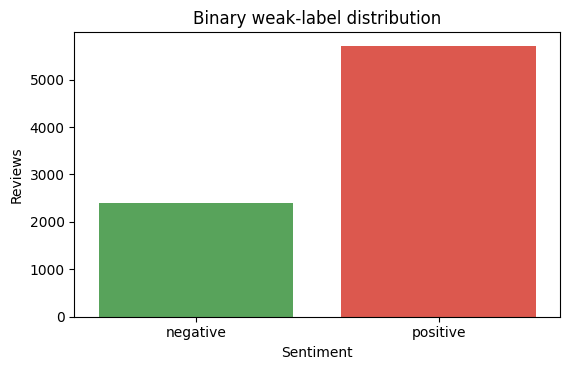

In [4]:
def rating_to_binary_base(rating: float | None) -> int | None:
    if rating is None or pd.isna(rating):
        return None
    rating = float(rating)
    if rating <= 2.0:
        return LABEL_MAP["negative"]
    if rating >= 4.0:
        return LABEL_MAP["positive"]
    return None


_NEGATIVE_KEYWORDS = [
    "tệ", "kém", "tồi", "chán", "thất vọng", "không tốt", "lương thấp",
    "quá tải", "áp lực", "bóc lột", "không công bằng", "thiếu chuyên nghiệp",
    "hay thay đổi", "không ổn định", "môi trường độc hại", "overtime",
    "không có cơ hội", "trì trệ", "lãnh đạo kém", "quan liêu",
    "không phù hợp", "không xứng đáng", "không minh bạch", "toxic",
]
_POSITIVE_KEYWORDS = [
    "tuyệt vời", "xuất sắc", "tốt", "chuyên nghiệp", "hài lòng", "lương cao",
    "phúc lợi", "cơ hội", "phát triển", "năng động", "thân thiện", "hỗ trợ",
    "linh hoạt", "ổn định", "học hỏi", "sáng tạo", "đãi ngộ tốt",
    "đồng nghiệp tốt", "cân bằng", "không phàn nàn", "không có gì phàn nàn",
    "không có gì để chê", "không có gì cần phàn nàn", "chịu khó", "kiên trì",
]
_ABSA_POSITIVE = [
    "tốt", "tuyệt", "ổn", "tích cực", "nhiệt tình", "rõ ràng", "minh bạch",
    "công bằng", "hỗ trợ", "vui", "thân thiện", "chuyên nghiệp", "năng động",
    "cởi mở", "hợp lý", "xứng đáng", "phù hợp", "ổn định", "hiệu quả",
    "tuyệt vời", "hài lòng", "thoải mái", "cạnh tranh", "tận tâm", "quan tâm",
    "không phàn nàn", "không có gì phàn nàn", "không có gì để chê",
]
_ABSA_NEGATIVE = [
    "không tốt", "không ổn", "không phù hợp", "không xứng đáng", "tệ", "kém",
    "chậm", "áp lực", "stress", "thấp", "thiếu", "ràng buộc", "bất công",
    "drama", "độc đoán", "toxic", "khắc khe", "ì ạch", "trễ", "cũ kỹ",
    "thất vọng", "khó khăn", "quá tải", "mệt", "chán", "không minh bạch",
    "không công bằng", "không hợp lý", "bóc lột", "thiếu chuyên nghiệp",
]


def _keyword_score(text: str) -> float:
    if not text or pd.isna(text):
        return 0.0
    t = str(text).lower()
    pos = sum(1 for kw in _POSITIVE_KEYWORDS if kw in t)
    neg = sum(1 for kw in _NEGATIVE_KEYWORDS if kw in t)
    return float(pos - neg)


def _absa_score(title: str, pros: str, cons: str, advice: str) -> float:
    def _field_score(text: str, weight: float = 1.0) -> float:
        if not text or pd.isna(text):
            return 0.0
        t = str(text).lower()
        pos = sum(1 for w in _ABSA_POSITIVE if w in t)
        neg = sum(1 for w in _ABSA_NEGATIVE if w in t)
        return (pos - neg) * weight

    # In this CSV, `cons` often stores the full review body, so it is not forced negative.
    return (
        _field_score(title, 1.0)
        + _field_score(pros, 1.0)
        + _field_score(cons, 1.0)
        + _field_score(advice, 0.5)
    )


def weak_label_binary(rating: float | None, pros: str, cons: str, advice: str, title: str = "") -> tuple[int | None, str, float]:
    base = rating_to_binary_base(rating)
    all_text = " ".join(str(x) for x in [title, pros, cons, advice])
    combined = _keyword_score(all_text) + _absa_score(title, pros, cons, advice)

    if base is None:
        if combined <= -2.5:
            return LABEL_MAP["negative"], "rating3_to_negative_strong_absa", combined
        if combined >= 2.5:
            return LABEL_MAP["positive"], "rating3_to_positive_strong_absa", combined
        return None, "drop_neutral_or_weak_signal", combined

    if base == LABEL_MAP["positive"] and combined <= -5:
        return LABEL_MAP["negative"], "positive_to_negative_absa_override", combined
    if base == LABEL_MAP["positive"] and combined <= -2:
        return None, "drop_positive_text_conflict", combined
    if base == LABEL_MAP["negative"] and combined >= 5:
        return LABEL_MAP["positive"], "negative_to_positive_absa_override", combined
    if base == LABEL_MAP["negative"] and combined >= 2:
        return None, "drop_negative_text_conflict", combined
    return base, "rating", combined


def make_binary_dataframe(df: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    records = []
    dropped = []
    for idx, row in df.iterrows():
        parts = []
        for col in ["title", "pros", "cons", "advice"]:
            val = row.get(col, "")
            if pd.notna(val) and str(val).strip():
                parts.append(str(val).strip())
        text = " ".join(parts)
        if not text.strip():
            dropped.append({"row_id": idx, "label_source": "drop_empty_text"})
            continue

        title = str(row.get("title") or "")
        pros = str(row.get("pros") or "")
        cons = str(row.get("cons") or "")
        advice = str(row.get("advice") or "")
        rating = row.get("rating")
        base = rating_to_binary_base(rating)
        label, label_source, signal_score = weak_label_binary(rating, pros, cons, advice, title=title)

        if label is None:
            dropped.append({
                "row_id": idx,
                "rating": rating,
                "rating_base": LABEL_NAMES.get(base, "none"),
                "label_source": label_source,
                "signal_score": signal_score,
            })
            continue

        records.append({
            "row_id": idx,
            "text": text,
            "rating": rating,
            "rating_base": base,
            "label_id": label,
            "label_name": LABEL_NAMES[label],
            "label_source": label_source,
            "signal_score": signal_score,
            "company": row.get("company", ""),
            "industry": row.get("industry", ""),
        })
    return pd.DataFrame(records), pd.DataFrame(dropped)


labeled_df, dropped_df = make_binary_dataframe(raw_df)
if MAX_EXAMPLES is not None:
    labeled_df = labeled_df.sample(n=min(MAX_EXAMPLES, len(labeled_df)), random_state=SEED).reset_index(drop=True)

base_available = labeled_df["rating_base"].notna()
changed = base_available & (labeled_df["label_id"] != labeled_df["rating_base"])
print(f"Raw reviews: {len(raw_df):,}")
print(f"Binary usable rows: {len(labeled_df):,} ({len(labeled_df) / len(raw_df) * 100:.1f}%)")
print(f"Dropped rows: {len(dropped_df):,} ({len(dropped_df) / len(raw_df) * 100:.1f}%)")
print(f"Overrides among non-neutral ratings: {int(changed.sum()):,}")
print("\nBinary label distribution:")
print(labeled_df["label_name"].value_counts().reindex(CLASS_ORDER).to_string())
print("\nLabel source distribution:")
print(labeled_df["label_source"].value_counts().to_string())
print("\nDrop reason distribution:")
print(dropped_df.get("label_source", pd.Series(dtype=str)).value_counts().to_string())

fig, ax = plt.subplots(figsize=(5.8, 3.8))
sns.countplot(data=labeled_df, x="label_name", order=CLASS_ORDER, hue="label_name", legend=False, palette=["#F44336", "#4CAF50"], ax=ax)
ax.set_title("Binary weak-label distribution")
ax.set_xlabel("Sentiment")
ax.set_ylabel("Reviews")
plt.tight_layout()
plt.show()


## 3. PhoBERT Pre-segmentation, Split, and Dataloaders

In [5]:
def segment_for_phobert(text: str) -> str:
    text = str(text).replace("\n", " ").strip()
    if not text or not PRESEGMENT_FOR_PHOBERT:
        return text
    try:
        return word_tokenize(text, format="text")
    except Exception:
        return text


cache_path = OUTPUT_DIR / f"segmented_binary_reviews_{len(labeled_df)}_{'seg' if PRESEGMENT_FOR_PHOBERT else 'raw'}.csv"
if cache_path.exists():
    segmented_df = pd.read_csv(cache_path)
    print("Loaded segmentation cache:", cache_path)
else:
    segmented_df = labeled_df.copy()
    tqdm.pandas(desc="Segmenting")
    segmented_df["text_phobert"] = segmented_df["text"].progress_apply(segment_for_phobert)
    segmented_df.to_csv(cache_path, index=False, encoding="utf-8-sig")
    print("Saved segmentation cache:", cache_path)

train_df, temp_df = train_test_split(segmented_df, test_size=0.30, random_state=SEED, stratify=segmented_df["label_id"])
val_df, test_df = train_test_split(temp_df, test_size=0.50, random_state=SEED, stratify=temp_df["label_id"])
for name, split_df in [("train", train_df), ("val", val_df), ("test", test_df)]:
    counts = split_df["label_name"].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)
    print(name, len(split_df))
    print(counts.to_string())
    print()

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)


class ReviewDataset(Dataset):
    def __init__(self, frame: pd.DataFrame):
        self.texts = frame["text_phobert"].astype(str).tolist()
        self.labels = frame["label_id"].astype(int).tolist()

    def __len__(self) -> int:
        return len(self.labels)

    def __getitem__(self, idx: int) -> dict[str, torch.Tensor]:
        encoded = tokenizer(self.texts[idx], max_length=MAX_LEN, truncation=True, padding=False)
        encoded["labels"] = self.labels[idx]
        return encoded


collator = DataCollatorWithPadding(tokenizer=tokenizer)
train_loader = DataLoader(ReviewDataset(train_df), batch_size=BATCH_SIZE, shuffle=True, collate_fn=collator, num_workers=0)
val_loader = DataLoader(ReviewDataset(val_df), batch_size=BATCH_SIZE * 2, shuffle=False, collate_fn=collator, num_workers=0)
test_loader = DataLoader(ReviewDataset(test_df), batch_size=BATCH_SIZE * 2, shuffle=False, collate_fn=collator, num_workers=0)
batch = next(iter(train_loader))
print({k: tuple(v.shape) for k, v in batch.items()})


Segmenting:   0%|          | 0/8105 [00:00<?, ?it/s]

Saved segmentation cache: /content/phobert_binary_outputs/segmented_binary_reviews_8105_seg.csv
train 5673
label_name
negative    1675
positive    3998

val 1216
label_name
negative    359
positive    857

test 1216
label_name
negative    359
positive    857



/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

{'input_ids': (16, 126), 'attention_mask': (16, 126), 'labels': (16,)}


## 4. Train PhoBERT Binary

In [6]:
model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2, id2label=ID2LABEL, label2id=LABEL2ID).to(device)

if USE_CLASS_WEIGHTS:
    weights = compute_class_weight("balanced", classes=np.array(CLASS_IDS), y=train_df["label_id"].astype(int).values)
    class_weights = torch.tensor(weights, dtype=torch.float32, device=device)
else:
    class_weights = None
loss_fct = nn.CrossEntropyLoss(weight=class_weights)
print("Class weights:", None if class_weights is None else class_weights.detach().cpu().numpy().round(4).tolist())

optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
total_steps = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler = get_linear_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)


def metrics_from_preds(y_true: np.ndarray, y_pred: np.ndarray, loss: float | None = None) -> dict:
    report = classification_report(y_true, y_pred, labels=CLASS_IDS, target_names=CLASS_ORDER, output_dict=True, zero_division=0)
    result = {
        "accuracy": float(accuracy_score(y_true, y_pred)),
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_weighted": float(f1_score(y_true, y_pred, average="weighted", zero_division=0)),
        "precision_macro": float(precision_score(y_true, y_pred, average="macro", zero_division=0)),
        "recall_macro": float(recall_score(y_true, y_pred, average="macro", zero_division=0)),
        "negative_f1": float(report["negative"]["f1-score"]),
        "positive_f1": float(report["positive"]["f1-score"]),
        "confusion_matrix": confusion_matrix(y_true, y_pred, labels=CLASS_IDS).tolist(),
        "classification_report": report,
    }
    if loss is not None:
        result["loss"] = float(loss)
    return result


def train_one_epoch() -> float:
    model.train()
    total_loss = 0.0
    for batch in tqdm(train_loader, desc="train", leave=False):
        labels = batch["labels"].to(device)
        inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=USE_AMP):
            logits = model(**inputs).logits
            loss = loss_fct(logits, labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()
        total_loss += loss.item() * labels.size(0)
    return total_loss / len(train_loader.dataset)


@torch.no_grad()
def evaluate_loader(loader: DataLoader) -> dict:
    model.eval()
    total_loss = 0.0
    all_true = []
    all_pred = []
    for batch in tqdm(loader, desc="eval", leave=False):
        labels = batch["labels"].to(device)
        inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        logits = model(**inputs).logits
        loss = loss_fct(logits, labels)
        pred = logits.argmax(dim=-1)
        total_loss += loss.item() * labels.size(0)
        all_true.extend(labels.detach().cpu().numpy().tolist())
        all_pred.extend(pred.detach().cpu().numpy().tolist())
    return metrics_from_preds(np.array(all_true), np.array(all_pred), loss=total_loss / len(loader.dataset))


history = []
best_metric = -1.0
bad_epochs = 0
start = time.time()
for epoch in range(1, EPOCHS + 1):
    train_loss = train_one_epoch()
    val_metrics = evaluate_loader(val_loader)
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "val_loss": val_metrics["loss"],
        "val_accuracy": val_metrics["accuracy"],
        "val_f1_macro": val_metrics["f1_macro"],
        "val_negative_f1": val_metrics["negative_f1"],
        "val_positive_f1": val_metrics["positive_f1"],
    }
    history.append(row)
    print(
        f"Epoch {epoch}: train_loss={train_loss:.4f} "
        f"val_loss={val_metrics['loss']:.4f} "
        f"val_acc={val_metrics['accuracy']:.4f} "
        f"val_f1={val_metrics['f1_macro']:.4f}"
    )
    if val_metrics["f1_macro"] > best_metric + 1e-5:
        best_metric = val_metrics["f1_macro"]
        bad_epochs = 0
        BEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)
        model.save_pretrained(BEST_MODEL_DIR)
        tokenizer.save_pretrained(BEST_MODEL_DIR)
        print("  saved best model")
    else:
        bad_epochs += 1
        print(f"  no improvement ({bad_epochs}/{PATIENCE})")
        if bad_epochs >= PATIENCE:
            print("Early stopping.")
            break

elapsed_min = (time.time() - start) / 60
history_df = pd.DataFrame(history)
print(f"Training time: {elapsed_min:.1f} min")
history_df


pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                             | Status     | 
--------------------------------+------------+-
lm_head.bias                    | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
lm_head.dense.weight            | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.dense.bias           | MISSING    | 
classifier.out_proj.weight      | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

Class weights: [1.6934000253677368, 0.7095000147819519]


...

train:   0%|          | 0/355 [00:00<?, ?it/s]

/tmp/ipykernel_2376/1585253612.py:43: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=USE_AMP):


eval:   0%|          | 0/38 [00:00<?, ?it/s]

Epoch 4: train_loss=0.0429 val_loss=0.2617 val_acc=0.9523 val_f1=0.9420
  no improvement (1/2)
Training time: 5.3 min


,epoch,train_loss,val_loss,val_accuracy,val_f1_macro,val_negative_f1,val_positive_f1
0,1,0.286215,0.183865,0.950658,0.940905,0.916898,0.964912
1,2,0.131438,0.177268,0.956414,0.947841,0.926694,0.968988
2,3,0.080115,0.230356,0.958059,0.949234,0.928068,0.970400
3,4,0.042944,0.261686,0.952303,0.942024,0.917614,0.966435


## 5. Tune Threshold and Evaluate Test Set

In [7]:
model = AutoModelForSequenceClassification.from_pretrained(BEST_MODEL_DIR).to(device)
model.eval()


@torch.no_grad()
def collect_probs(loader: DataLoader) -> tuple[np.ndarray, np.ndarray]:
    all_true = []
    all_probs = []
    for batch in tqdm(loader, desc="probs", leave=False):
        labels = batch["labels"].to(device)
        inputs = {k: v.to(device) for k, v in batch.items() if k != "labels"}
        logits = model(**inputs).logits
        probs = torch.softmax(logits, dim=-1)
        all_true.extend(labels.detach().cpu().numpy().tolist())
        all_probs.extend(probs.detach().cpu().numpy().tolist())
    return np.array(all_true), np.array(all_probs)


def predict_with_positive_threshold(probs: np.ndarray, threshold: float) -> np.ndarray:
    return (probs[:, LABEL_MAP["positive"]] >= threshold).astype(int)


val_true, val_probs = collect_probs(val_loader)
base_val_metrics = metrics_from_preds(val_true, val_probs.argmax(axis=1))
threshold_rows = []
for threshold in np.round(np.arange(0.20, 0.801, 0.01), 2):
    pred = predict_with_positive_threshold(val_probs, float(threshold))
    m = metrics_from_preds(val_true, pred)
    threshold_rows.append({
        "positive_threshold": float(threshold),
        "accuracy": m["accuracy"],
        "f1_macro": m["f1_macro"],
        "negative_f1": m["negative_f1"],
        "positive_f1": m["positive_f1"],
    })
threshold_df = pd.DataFrame(threshold_rows).sort_values(["f1_macro", "accuracy"], ascending=False)
best_threshold = float(threshold_df.iloc[0]["positive_threshold"])
print("Base validation:", {k: round(base_val_metrics[k], 4) for k in ["accuracy", "f1_macro", "negative_f1", "positive_f1"]})
print("Best positive threshold:", best_threshold)

test_true, test_probs = collect_probs(test_loader)
test_metrics = metrics_from_preds(test_true, test_probs.argmax(axis=1))
threshold_test_metrics = metrics_from_preds(test_true, predict_with_positive_threshold(test_probs, best_threshold))

summary_df = pd.DataFrame([
    {
        "model": BASELINE_TFIDF_BINARY["name"],
        "accuracy": BASELINE_TFIDF_BINARY["accuracy"],
        "f1_macro": BASELINE_TFIDF_BINARY["f1_macro"],
        "negative_f1": np.nan,
        "positive_f1": np.nan,
    },
    {
        "model": "PhoBERT_Binary",
        "accuracy": test_metrics["accuracy"],
        "f1_macro": test_metrics["f1_macro"],
        "negative_f1": test_metrics["negative_f1"],
        "positive_f1": test_metrics["positive_f1"],
    },
    {
        "model": f"PhoBERT_Binary_Threshold_{best_threshold:.2f}",
        "accuracy": threshold_test_metrics["accuracy"],
        "f1_macro": threshold_test_metrics["f1_macro"],
        "negative_f1": threshold_test_metrics["negative_f1"],
        "positive_f1": threshold_test_metrics["positive_f1"],
    },
])
display(threshold_df.head(10).round(4))
display(summary_df.round(4))


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

probs:   0%|          | 0/38 [00:00<?, ?it/s]

Base validation: {'accuracy': 0.9581, 'f1_macro': 0.9492, 'negative_f1': 0.9281, 'positive_f1': 0.9704}
Best positive threshold: 0.68


probs:   0%|          | 0/38 [00:00<?, ?it/s]

,positive_threshold,accuracy,f1_macro,negative_f1,positive_f1
48,0.68,0.9581,0.9495,0.9287,0.9703
49,0.69,0.9581,0.9495,0.9287,0.9703
50,0.70,0.9581,0.9495,0.9287,0.9703
51,0.71,0.9581,0.9495,0.9287,0.9703
52,0.72,0.9581,0.9495,0.9287,0.9703
53,0.73,0.9581,0.9495,0.9287,0.9703
54,0.74,0.9581,0.9495,0.9287,0.9703
55,0.75,0.9581,0.9495,0.9287,0.9703
56,0.76,0.9581,0.9495,0.9287,0.9703
57,0.77,0.9581,0.9495,0.9287,0.9703


,model,accuracy,f1_macro,negative_f1,positive_f1
0,TF-IDF_WordChar_LinearSVC_Binary_NoNeutral,0.9325,0.9184,NaN,NaN
1,PhoBERT_Binary,0.9646,0.9575,0.9402,0.9749
2,PhoBERT_Binary_Threshold_0.68,0.9663,0.9596,0.9431,0.9760


## 6. Visualizations and Save Results

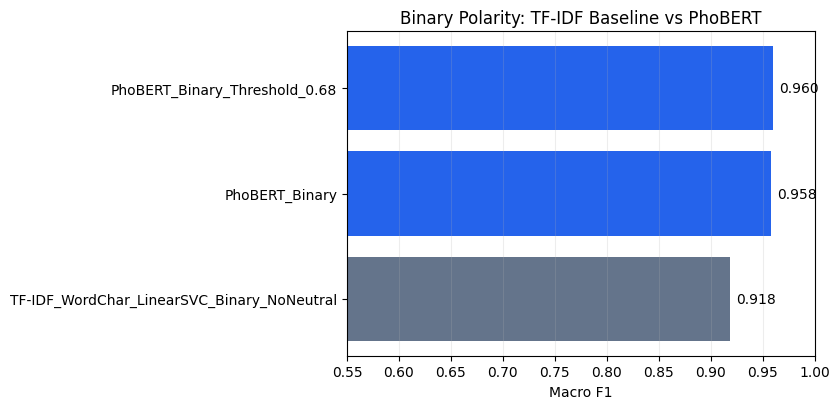

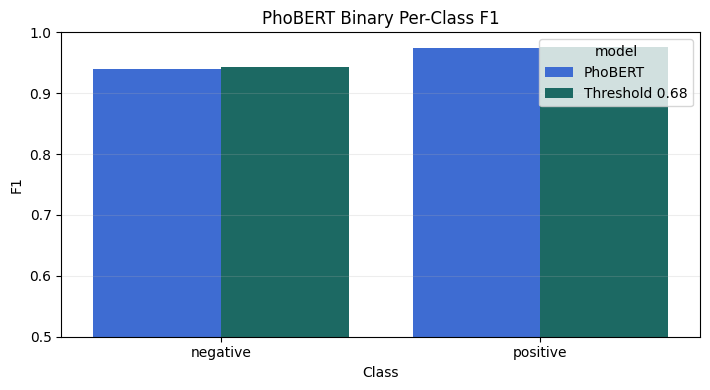

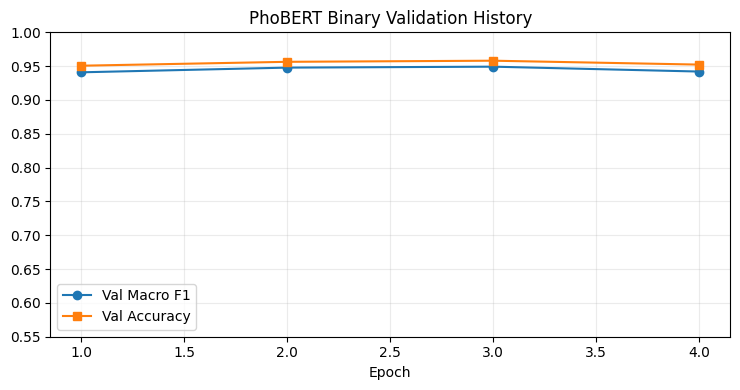

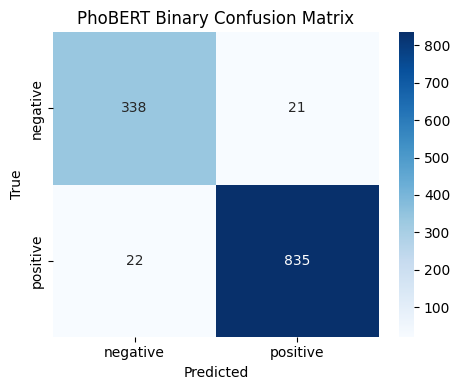

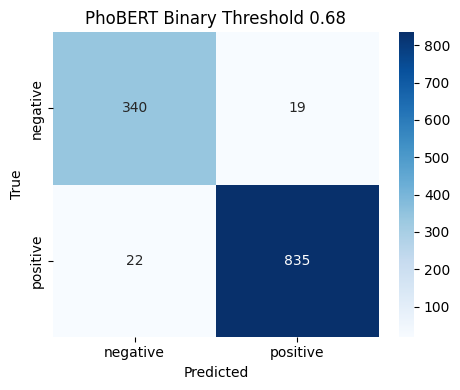

Saved: /content/phobert_binary_outputs/phobert_binary_results.json
Saved: /content/phobert_binary_outputs/phobert_binary_report.md
Output files:
- /content/phobert_binary_outputs/chart_phobert_binary_comparison.png
- /content/phobert_binary_outputs/chart_phobert_binary_confusion_matrix.png
- /content/phobert_binary_outputs/chart_phobert_binary_per_class_f1.png
- /content/phobert_binary_outputs/chart_phobert_binary_threshold_confusion_matrix.png
- /content/phobert_binary_outputs/chart_phobert_binary_training_history.png
- /content/phobert_binary_outputs/phobert_binary_report.md
- /content/phobert_binary_outputs/phobert_binary_results.json
- /content/phobert_binary_outputs/phobert_binary_test_comparison.csv
- /content/phobert_binary_outputs/phobert_binary_threshold_search.csv
- /content/phobert_binary_outputs/segmented_binary_reviews_8105_seg.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [8]:
def plot_confusion(cm: list[list[int]], title: str, path: Path) -> None:
    fig, ax = plt.subplots(figsize=(4.8, 4.0))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=CLASS_ORDER, yticklabels=CLASS_ORDER, ax=ax)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout()
    fig.savefig(path, dpi=160, bbox_inches="tight")
    plt.show()


comparison_path = OUTPUT_DIR / "chart_phobert_binary_comparison.png"
fig, ax = plt.subplots(figsize=(8.5, 4.2))
plot_df = summary_df.sort_values("f1_macro", ascending=True)
colors = ["#64748b" if "TF-IDF" in m else "#2563eb" for m in plot_df["model"]]
bars = ax.barh(plot_df["model"], plot_df["f1_macro"], color=colors)
ax.set_xlim(0.55, 1.0)
ax.set_xlabel("Macro F1")
ax.set_title("Binary Polarity: TF-IDF Baseline vs PhoBERT")
ax.grid(True, axis="x", alpha=0.22)
for bar, value in zip(bars, plot_df["f1_macro"]):
    ax.text(value + 0.006, bar.get_y() + bar.get_height() / 2, f"{value:.3f}", va="center")
plt.tight_layout()
fig.savefig(comparison_path, dpi=160, bbox_inches="tight")
plt.show()

per_class_path = OUTPUT_DIR / "chart_phobert_binary_per_class_f1.png"
per_class_df = pd.DataFrame([
    {"class": "negative", "f1": test_metrics["negative_f1"], "model": "PhoBERT"},
    {"class": "positive", "f1": test_metrics["positive_f1"], "model": "PhoBERT"},
    {"class": "negative", "f1": threshold_test_metrics["negative_f1"], "model": f"Threshold {best_threshold:.2f}"},
    {"class": "positive", "f1": threshold_test_metrics["positive_f1"], "model": f"Threshold {best_threshold:.2f}"},
])
fig, ax = plt.subplots(figsize=(7.2, 4.0))
sns.barplot(data=per_class_df, x="class", y="f1", hue="model", palette=["#2563eb", "#0f766e"], ax=ax)
ax.set_ylim(0.5, 1.0)
ax.set_xlabel("Class")
ax.set_ylabel("F1")
ax.set_title("PhoBERT Binary Per-Class F1")
ax.grid(True, axis="y", alpha=0.22)
plt.tight_layout()
fig.savefig(per_class_path, dpi=160, bbox_inches="tight")
plt.show()

history_path = OUTPUT_DIR / "chart_phobert_binary_training_history.png"
fig, ax = plt.subplots(figsize=(7.5, 4.0))
ax.plot(history_df["epoch"], history_df["val_f1_macro"], marker="o", label="Val Macro F1")
ax.plot(history_df["epoch"], history_df["val_accuracy"], marker="s", label="Val Accuracy")
ax.set_xlabel("Epoch")
ax.set_ylim(0.55, 1.0)
ax.set_title("PhoBERT Binary Validation History")
ax.grid(True, alpha=0.25)
ax.legend()
plt.tight_layout()
fig.savefig(history_path, dpi=160, bbox_inches="tight")
plt.show()

plot_confusion(test_metrics["confusion_matrix"], "PhoBERT Binary Confusion Matrix", OUTPUT_DIR / "chart_phobert_binary_confusion_matrix.png")
plot_confusion(threshold_test_metrics["confusion_matrix"], f"PhoBERT Binary Threshold {best_threshold:.2f}", OUTPUT_DIR / "chart_phobert_binary_threshold_confusion_matrix.png")

class_dist = labeled_df["label_name"].value_counts().reindex(CLASS_ORDER).fillna(0).astype(int)
results = {
    "model_name": MODEL_NAME,
    "task": "binary_no_neutral",
    "csv_path": str(CSV_PATH),
    "raw_review_count": int(len(raw_df)),
    "binary_usable_count": int(len(labeled_df)),
    "dropped_count": int(len(dropped_df)),
    "class_distribution": {k: int(v) for k, v in class_dist.items()},
    "split": {"train": len(train_df), "val": len(val_df), "test": len(test_df)},
    "training_minutes": round(float(elapsed_min), 2),
    "config": {
        "max_len": MAX_LEN,
        "batch_size": BATCH_SIZE,
        "epochs_requested": EPOCHS,
        "epochs_completed": int(history_df["epoch"].max()),
        "learning_rate": LEARNING_RATE,
        "class_weights": USE_CLASS_WEIGHTS,
        "presegment_for_phobert": PRESEGMENT_FOR_PHOBERT,
        "best_positive_threshold": best_threshold,
    },
    "history": history_df.round(6).to_dict("records"),
    "threshold_candidates": threshold_df.round(6).to_dict("records"),
    "test_comparison": summary_df.round(6).to_dict("records"),
    "phobert_binary": {k: v for k, v in test_metrics.items() if k != "classification_report"},
    "phobert_binary_threshold": {k: v for k, v in threshold_test_metrics.items() if k != "classification_report"},
}

json_path = OUTPUT_DIR / "phobert_binary_results.json"
json_path.write_text(json.dumps(results, ensure_ascii=False, indent=2), encoding="utf-8")
summary_df.to_csv(OUTPUT_DIR / "phobert_binary_test_comparison.csv", index=False, encoding="utf-8-sig")
threshold_df.to_csv(OUTPUT_DIR / "phobert_binary_threshold_search.csv", index=False, encoding="utf-8-sig")

best_row = summary_df.sort_values("f1_macro", ascending=False).iloc[0]
report = f"""# PhoBERT Binary No-Neutral Result

## Setup
- Task: binary sentiment classification (`negative` / `positive`)
- Neutral policy: rating 3 and weak/conflicted cases are dropped; rating 3 is kept only when ABSA/keyword signal is strong
- Model: `{MODEL_NAME}`
- Raw reviews: {len(raw_df):,}
- Binary usable rows: {len(labeled_df):,} ({len(labeled_df) / len(raw_df) * 100:.1f}%)
- Dropped rows: {len(dropped_df):,} ({len(dropped_df) / len(raw_df) * 100:.1f}%)
- Split: train {len(train_df):,}, validation {len(val_df):,}, test {len(test_df):,}

## Test Results

{summary_df.round(4).to_markdown(index=False)}

## Best Validation Threshold
- Positive threshold: `{best_threshold:.2f}`
- Best model in comparison table: `{best_row['model']}` with Macro F1 `{best_row['f1_macro']:.4f}`

## Interpretation
TF-IDF binary is still the baseline to beat in the current slide/report. PhoBERT binary is the transformer benchmark for the same no-neutral setting.
"""
md_path = OUTPUT_DIR / "phobert_binary_report.md"
md_path.write_text(report, encoding="utf-8")

print("Saved:", json_path)
print("Saved:", md_path)
print("Output files:")
for path in sorted(OUTPUT_DIR.glob("*")):
    if path.is_file():
        print("-", path)

if IN_COLAB:
    archive = shutil.make_archive(str(OUTPUT_DIR), "zip", OUTPUT_DIR)
    from google.colab import files
    files.download(archive)
